In [1]:
import ast
import seaborn as sns
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
from adjustText import adjust_text
 
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
 
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])
df_DA_US = df_DA_US.explode('job_skills')

In [3]:
total_DA_jobs = df_DA_US.drop(columns='job_skills').drop_duplicates().shape[0]
 
df_DA_skills_high_demand = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).reset_index()
df_DA_skills_high_demand = df_DA_skills_high_demand.rename(columns={'median': 'median_salary'})
df_DA_skills_high_demand['skill_percent'] = df_DA_skills_high_demand['count'] / total_DA_jobs * 100
df_DA_skills_high_demand = df_DA_skills_high_demand[df_DA_skills_high_demand['skill_percent'] > 5]
 
skill_categories = {
    'python': 'programming', 'sql': 'programming', 'r': 'programming', 'go': 'programming', 'sas': 'programming',
    'tableau': 'analyst_tools', 'power bi': 'analyst_tools', 'excel': 'analyst_tools',
    'powerpoint': 'analyst_tools', 'word': 'analyst_tools',
    'sql server': 'databases', 'oracle': 'cloud',
}
df_DA_skills_high_demand['technology'] = df_DA_skills_high_demand['job_skills'].map(skill_categories)
 
df_DA_skills_high_demand.head()

,job_skills,count,median_salary,skill_percent,technology
42,excel,1808,84392.00,41.572775,analyst_tools
54,go,224,90000.00,5.150609,programming
94,oracle,274,96923.75,6.300299,cloud
103,power bi,838,90000.00,19.268797,analyst_tools
104,powerpoint,462,85000.00,10.623132,analyst_tools


In [4]:
total_DA_jobs = df_DA_US.drop(columns='job_skills').drop_duplicates().shape[0]
 
df_DA_skills_high_demand = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).reset_index()
df_DA_skills_high_demand = df_DA_skills_high_demand.rename(columns={'median': 'median_salary'})
df_DA_skills_high_demand['skill_percent'] = df_DA_skills_high_demand['count'] / total_DA_jobs * 100
df_DA_skills_high_demand = df_DA_skills_high_demand[df_DA_skills_high_demand['skill_percent'] > 5]
 
skill_categories = {
    'python': 'programming', 'sql': 'programming', 'r': 'programming', 'go': 'programming', 'sas': 'programming',
    'tableau': 'analyst_tools', 'power bi': 'analyst_tools', 'excel': 'analyst_tools',
    'powerpoint': 'analyst_tools', 'word': 'analyst_tools',
    'sql server': 'databases', 'oracle': 'cloud',
}
df_DA_skills_high_demand['technology'] = df_DA_skills_high_demand['job_skills'].map(skill_categories)
 
df_DA_skills_high_demand.head()

,job_skills,count,median_salary,skill_percent,technology
42,excel,1808,84392.00,41.572775,analyst_tools
54,go,224,90000.00,5.150609,programming
94,oracle,274,96923.75,6.300299,cloud
103,power bi,838,90000.00,19.268797,analyst_tools
104,powerpoint,462,85000.00,10.623132,analyst_tools


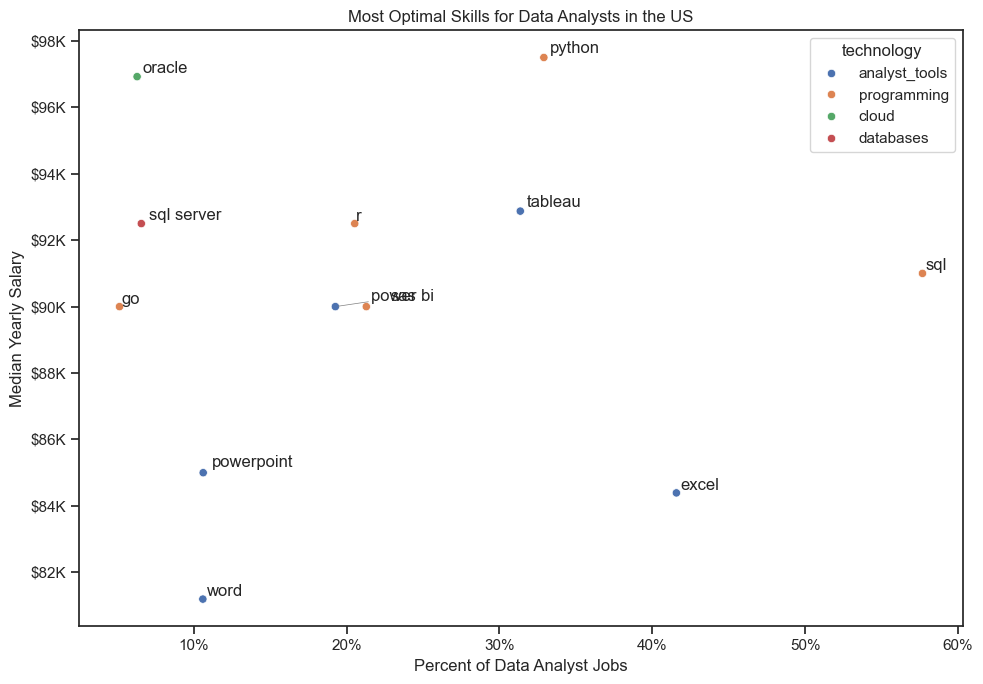

In [5]:
sns.set_theme(style="ticks")
fig, ax = plt.subplots(figsize=(10, 7))

sns.scatterplot(
    data=df_DA_skills_high_demand,
    x='skill_percent',
    y='median_salary',
    hue='technology',
    ax=ax
)

texts = []
for i, row in df_DA_skills_high_demand.iterrows():
    texts.append(plt.text(row['skill_percent'], row['median_salary'], row['job_skills']))
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

ax.set_title('Most Optimal Skills for Data Analysts in the US')
ax.set_xlabel('Percent of Data Analyst Jobs')
ax.set_ylabel('Median Yearly Salary')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}%'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'${int(y/1000)}K'))

plt.tight_layout()
plt.show()